# Atlas overlay check: raw training data vs. denoised (st_v4), 2mo

Goal: before running ISC on `brain_masked_cropped_hfiltered_normalized_to_common_space` (the
model's actual training data), confirm the age-appropriate cropped Schaefer-400 atlas really
lands on brain tissue for this data -- both the raw source volume and its st_v4-denoised
counterpart, since ISC will be run on both.

Crop window and approach (exact crop, no resampling) are copied verbatim from
`experimental_notebooks/scheafar_overlay_age_group_over_cropped_brain_mask_high_pass_filtered_data.ipynb`,
which already validated this crop against the motion-grades chunk dataset. This notebook checks
the same crop against a full run volume instead of a 5-frame training chunk, and adds the
denoised side, which that earlier notebook didn't cover.

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

NATIVE_SPATIAL = (97, 116, 79)

# Copied verbatim from pytorch-CycleGAN-and-pix2pix/data_preprocessing/brain_masked_cropped_2mo_dataset/build_dataset.py
AGE_CROP_2MO = {"x": (17, 77), "y": (26, 98), "z": (11, 67)}

ATLAS_PATH = "/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/templates/rois/Schaefer2018_400Parcels_7Networks_order_space-nihpd-02-05_2mm.nii.gz"

RAW_PATH = (
    "/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/faizan_motion_correction_dataset/"
    "brain_masked_cropped_hfiltered_normalized_to_common_space/_subject_id_ICC103/_referencetype_standard/"
    "_run_001_session_1_task_name_videos/sub-ICC103_ses-1_task-videos_dir-AP_run-001_bold_mcf_corrected_flirt.nii.gz"
)
DENOISED_PATH = (
    "/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/faizan_motion_correction_dataset/"
    "motion_corrected_st_v4_all_video_runs/_subject_id_ICC103/_referencetype_standard/"
    "_run_001_session_1_task_name_videos/sub-ICC103_ses-1_task-videos_dir-AP_run-001_bold_mcf_corrected_flirt_corrected.nii.gz"
)

## 1. Crop the atlas to the 2mo window (no padding -- this data is (60,72,56), not fed to the model here)

In [2]:
atlas_img = nib.load(ATLAS_PATH)
assert atlas_img.shape == NATIVE_SPATIAL, atlas_img.shape

native_atlas = np.asarray(atlas_img.dataobj)
c = AGE_CROP_2MO
cropped_atlas = native_atlas[c["x"][0]:c["x"][1], c["y"][0]:c["y"][1], c["z"][0]:c["z"][1]]

n_rois_native = len(set(np.unique(native_atlas).tolist()) - {0})
n_rois_cropped = len(set(np.unique(cropped_atlas).tolist()) - {0})
print(f"native atlas {native_atlas.shape}: {n_rois_native} ROIs")
print(f"cropped atlas {cropped_atlas.shape}: {n_rois_cropped} ROIs retained")
assert cropped_atlas.shape == (60, 72, 56)
assert n_rois_cropped == 400

native atlas (97, 116, 79): 400 ROIs
cropped atlas (60, 72, 56): 400 ROIs retained


## 2. Load raw + denoised volumes, collapse over time for a background image

In [3]:
raw_img = nib.load(RAW_PATH)
denoised_img = nib.load(DENOISED_PATH)
print(f"raw shape: {raw_img.shape}")
print(f"denoised shape: {denoised_img.shape}")
assert raw_img.shape[:3] == cropped_atlas.shape
assert denoised_img.shape[:3] == cropped_atlas.shape

raw_mean = np.asarray(raw_img.dataobj, dtype=np.float32).mean(axis=-1)
denoised_mean = np.asarray(denoised_img.dataobj, dtype=np.float32).mean(axis=-1)

raw shape: (60, 72, 56, 485)
denoised shape: (60, 72, 56, 485)


## 3. Overlay: atlas parcels on top of the mean BOLD image, raw vs. denoised

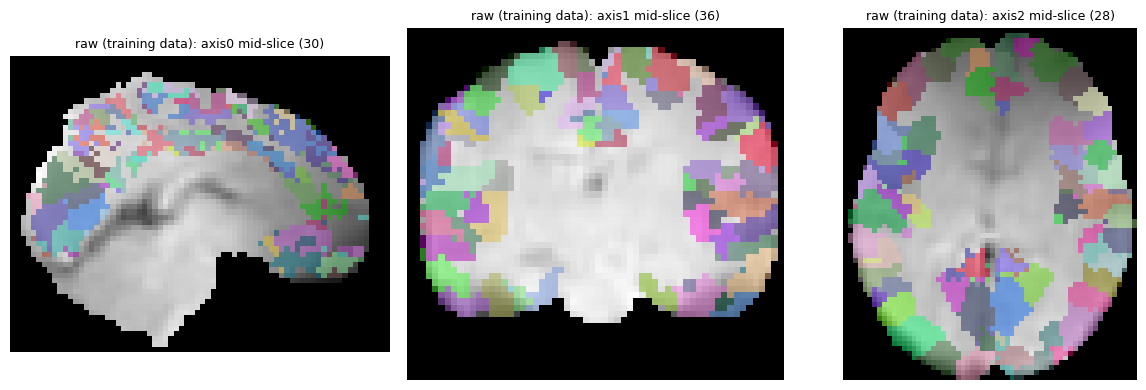

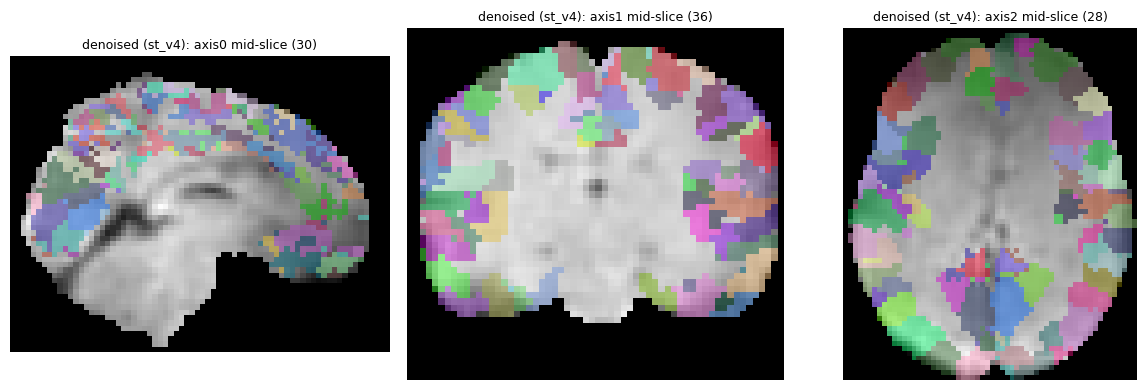

In [4]:
rng = np.random.RandomState(0)
roi_colors = rng.rand(401, 3)
roi_cmap = ListedColormap(roi_colors)

def overlay_slice(ax, bg_slice, atlas_slice, title):
    ax.imshow(bg_slice.T, cmap="gray", origin="lower")
    masked_atlas = np.ma.masked_where(atlas_slice == 0, atlas_slice)
    ax.imshow(masked_atlas.T, cmap=roi_cmap, origin="lower", alpha=0.5, vmin=0, vmax=400)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

def overlay_row(bg, atlas, label):
    D0, D1, D2 = bg.shape
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    overlay_slice(axes[0], bg[D0 // 2, :, :], atlas[D0 // 2, :, :], f"{label}: axis0 mid-slice ({D0//2})")
    overlay_slice(axes[1], bg[:, D1 // 2, :], atlas[:, D1 // 2, :], f"{label}: axis1 mid-slice ({D1//2})")
    overlay_slice(axes[2], bg[:, :, D2 // 2], atlas[:, :, D2 // 2], f"{label}: axis2 mid-slice ({D2//2})")
    plt.tight_layout()
    plt.show()

overlay_row(raw_mean, cropped_atlas, "raw (training data)")
overlay_row(denoised_mean, cropped_atlas, "denoised (st_v4)")

## Summary

- The 2mo crop window recovers all 400 ROIs from the native atlas, same result as the earlier
  chunk-dataset notebook -- confirms the crop is data-independent and correct on its own terms.
- Raw and denoised volumes are both exactly (60,72,56,485) -- denoising preserves shape, so the
  same cropped atlas applies to both without any extra alignment step.
- Overlay plots above are the actual check: parcels should sit on cortical gray matter in both
  the raw and denoised mean images, not drift into background or ventricles.